# The Faithfulness Benchmark: Does Each XAI Method Recover Known Ground Truth?

This is the headline notebook of the paper. We inject synthetic ground-truth signal
columns into the real 57-stock panel (pure noise; a strong linear signal at
rho=0.15; a weak linear signal at rho=0.05; a nonlinear sign*magnitude interaction
signal; an exact duplicate and a partially-collinear rho=0.8 duplicate of
`vol_z20`), then ask: does each XAI method's attribution rank the true signal
feature above the pure-noise feature, on a per-stock basis, across the 57-stock
universe?

Every number below is loaded directly from `results/metrics/faithfulness_benchmark.json`,
the same file `make_tables.py` reads to generate `paper/tables/tab_faithfulness_benchmark.tex`,
`tab_faithfulness_weak_signal.tex`, and `tab_paired_tests.tex`. Nothing here is
recomputed or hand-typed; we only load, reshape, and plot.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

METRICS = "../results/metrics"

with open(f"{METRICS}/faithfulness_benchmark.json") as f:
    fb = json.load(f)

print("Top-level keys:", list(fb.keys()))
print("Universe N symbols:", fb["universe_n_symbols"])
print("Cross-sectional rho_bar:", fb["cross_sectional_rho_bar"])
print("Effective N:", fb["effective_n"])
print("n_bootstrap resamples:", fb["n_bootstrap"])
print("Cluster unit:", fb["cluster_unit"])
print()
print("Methods scored:", [m["method"] for m in fb["methods"]])

Top-level keys: ['universe_n_symbols', 'cross_sectional_rho_bar', 'effective_n', 'n_bootstrap', 'cluster_unit', 'methods', 'paired_tests_permutation_vs_shap_lime', 'note']
Universe N symbols: 57
Cross-sectional rho_bar: 0.38135134265767284
Effective N: 2.549688144891318
n_bootstrap resamples: 5000
Cluster unit: symbol

Methods scored: ['treeshap', 'kernelshap', 'lime', 'permutation']


## Bootstrap protocol

The benchmark statistics (mean margin, 95% CI, %symbols) are each computed with a
**whole-symbol resampling bootstrap**: for each of `n_bootstrap` = 5000 resamples,
the 57 stocks are resampled with replacement as whole units (never individual rows
within a stock), the statistic is recomputed on the resample, and the 95% CI is the
2.5th/97.5th percentile of the resulting distribution. Resampling whole symbols
(not rows) is what makes the CI honest under strong within-stock and cross-stock
dependence -- see the effective-N calculation below.

## Why N_eff = 2.55 despite N = 57 stocks

Even though the benchmark is built on 57 distinct stocks, they are not 57
independent observations: daily returns and news-driven attributions are
strongly cross-sectionally correlated (mean pairwise correlation rho_bar = 0.381
across the universe). The standard finite-population effective-sample-size
correction for a common pairwise correlation rho_bar is:

N_eff = N / (1 + (N-1) * rho_bar)

We reproduce this formula live below and confirm it matches the `effective_n`
field stored in the JSON exactly.

In [2]:
N = fb["universe_n_symbols"]
rho_bar = fb["cross_sectional_rho_bar"]
n_eff_live = N / (1 + (N - 1) * rho_bar)

print(f"N (nominal symbols)      = {N}")
print(f"rho_bar (mean pairwise)  = {rho_bar:.6f}")
print(f"N_eff, computed live     = {n_eff_live:.6f}")
print(f"N_eff, stored in JSON    = {fb['effective_n']:.6f}")
print(f"Match: {np.isclose(n_eff_live, fb['effective_n'])}")
print()
print(f"Interpretation: with rho_bar={rho_bar:.3f}, the 57-stock cross-section carries")
print(f"only about as much independent statistical information as {fb['effective_n']:.2f}")
print("truly independent stocks would. This is why the bootstrap resamples whole")
print("symbols (respecting the dependence) rather than treating rows as i.i.d.")

N (nominal symbols)      = 57
rho_bar (mean pairwise)  = 0.381351
N_eff, computed live     = 2.549688
N_eff, stored in JSON    = 2.549688
Match: True

Interpretation: with rho_bar=0.381, the 57-stock cross-section carries
only about as much independent statistical information as 2.55
truly independent stocks would. This is why the bootstrap resamples whole
symbols (respecting the dependence) rather than treating rows as i.i.d.


## The main grid: strong linear vs weak linear vs nonlinear signal recovery

For each of the 4 core attribution methods (TreeSHAP, KernelSHAP, LIME, Permutation
importance -- the only methods sharing a common model class and a full per-feature
ranking), we tabulate:

- **Margin**: mean(signal attribution rank) minus mean(noise attribution rank) advantage,
  expressed as `mean_signal_minus_noise_margin` (higher = signal ranked more clearly above noise)
- **95% CI**: clustered (whole-symbol-resampled) bootstrap interval
- **%Sym**: percent of the 57 stocks where the method ranks the true signal feature
  above the pure-noise feature
- **MDES**: minimum detectable effect size at this sample's power (`mdes_approx`)

...separately for the strong linear signal (rho=0.15, top-level fields), the
weak linear signal (rho=0.05, nested under `weak`), and the nonlinear
sign*magnitude interaction signal (nested under `nonlinear`).

In [3]:
rows = []
for m in fb["methods"]:
    if "mean_signal_minus_noise_margin" not in m:
        continue
    ci = m["ci95_clustered"]
    rows.append({
        "method": m["method"],
        "strong_linear_margin": m["mean_signal_minus_noise_margin"],
        "strong_linear_ci_lo": ci[0], "strong_linear_ci_hi": ci[1],
        "strong_linear_pct_sym": m["pct_symbols_signal_above_noise"] * 100,
        "strong_linear_mdes": m.get("mdes_approx"),
        "weak_margin": m["weak"]["mean_signal_minus_noise_margin"] if m.get("weak") else np.nan,
        "weak_pct_sym": m["weak"]["pct_symbols_signal_above_noise"] * 100 if m.get("weak") else np.nan,
        "weak_mdes": m["weak"].get("mdes_approx") if m.get("weak") else np.nan,
        "nonlinear_margin": m["nonlinear"]["mean_signal_minus_noise_margin"] if m.get("nonlinear") else np.nan,
        "nonlinear_pct_sym": m["nonlinear"]["pct_symbols_signal_above_noise"] * 100 if m.get("nonlinear") else np.nan,
    })
grid = pd.DataFrame(rows).set_index("method")
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
grid

,strong_linear_margin,strong_linear_ci_lo,strong_linear_ci_hi,strong_linear_pct_sym,strong_linear_mdes,weak_margin,weak_pct_sym,weak_mdes,nonlinear_margin,nonlinear_pct_sym
method,,,,,,,,,,
treeshap,0.1459,0.1413,0.1504,100.0000,0.0065,0.0518,100.0000,0.0024,0.1944,100.0000
kernelshap,0.0345,0.0331,0.0359,100.0000,0.0020,0.0122,100.0000,0.0006,0.0462,100.0000
lime,0.0576,0.0550,0.0601,100.0000,0.0037,0.0167,100.0000,0.0014,0.0674,100.0000
permutation,0.0214,0.0158,0.0272,78.9474,0.0085,0.0023,57.8947,0.0048,0.0372,89.4737


In [4]:
print("Signal recovery summary (strong linear rho=0.15, weak linear rho=0.05, nonlinear):\n")
for m in fb["methods"]:
    if "mean_signal_minus_noise_margin" not in m:
        continue
    name = m["method"]
    print(f"{name:12s} strong: margin={m['mean_signal_minus_noise_margin']:.4f}  "
          f"%sym={m['pct_symbols_signal_above_noise']*100:5.1f}%  "
          f"MDES={m.get('mdes_approx', float('nan')):.4f}  "
          f"(clears MDES by {m['mean_signal_minus_noise_margin']/m['mdes_approx']:.1f}x)")
    if m.get("weak"):
        w = m["weak"]
        print(f"{'':12s} weak:   margin={w['mean_signal_minus_noise_margin']:.4f}  "
              f"%sym={w['pct_symbols_signal_above_noise']*100:5.1f}%  MDES={w.get('mdes_approx', float('nan')):.4f}")
    if m.get("nonlinear"):
        nl = m["nonlinear"]
        print(f"{'':12s} nonlin: margin={nl['mean_signal_minus_noise_margin']:.4f}  "
              f"%sym={nl['pct_symbols_signal_above_noise']*100:5.1f}%")
    print()

Signal recovery summary (strong linear rho=0.15, weak linear rho=0.05, nonlinear):

treeshap     strong: margin=0.1459  %sym=100.0%  MDES=0.0065  (clears MDES by 22.4x)
             weak:   margin=0.0518  %sym=100.0%  MDES=0.0024
             nonlin: margin=0.1944  %sym=100.0%

kernelshap   strong: margin=0.0345  %sym=100.0%  MDES=0.0020  (clears MDES by 17.1x)
             weak:   margin=0.0122  %sym=100.0%  MDES=0.0006
             nonlin: margin=0.0462  %sym=100.0%

lime         strong: margin=0.0576  %sym=100.0%  MDES=0.0037  (clears MDES by 15.6x)
             weak:   margin=0.0167  %sym=100.0%  MDES=0.0014
             nonlin: margin=0.0674  %sym=100.0%

permutation  strong: margin=0.0214  %sym= 78.9%  MDES=0.0085  (clears MDES by 2.5x)
             weak:   margin=0.0023  %sym= 57.9%  MDES=0.0048
             nonlin: margin=0.0372  %sym= 89.5%



## Redundant-feature credit splitting

The panel also contains an **exact duplicate** and a **partially-collinear
(rho=0.8) duplicate** of `vol_z20`. A well-behaved attribution method should
split credit between the duplicate and the source feature roughly evenly (share
near 0.5 each) for the exact duplicate, since the two columns are informationally
identical and the model cannot distinguish which one it used.

In [5]:
credit_rows = []
for m in fb["methods"]:
    if "mean_redundant_copy_credit_share" not in m:
        continue
    credit_rows.append({
        "method": m["method"],
        "exact_duplicate_credit_share": m["mean_redundant_copy_credit_share"],
        "partial_duplicate_credit_share": m["mean_redundant_partial_credit_share"],
    })
credit_df = pd.DataFrame(credit_rows).set_index("method")
print("Credit-share to the redundant COPY feature (0.5 = perfectly even split with the source):")
credit_df

Credit-share to the redundant COPY feature (0.5 = perfectly even split with the source):


,exact_duplicate_credit_share,partial_duplicate_credit_share
method,,
treeshap,0.1942,0.4494
kernelshap,0.2068,0.4843
lime,0.3591,0.3737
permutation,0.2775,0.1210


## Paired reliability tests: is permutation importance measurably less reliable?

`paired_tests_permutation_vs_shap_lime` pairs permutation importance's per-symbol
signal-vs-noise outcome against each of TreeSHAP, KernelSHAP, and LIME on the
common scored symbols, using two independent paired tests:

- **McNemar's test**: on the binary (correct/incorrect signal-above-noise) outcome per symbol
- **Wilcoxon signed-rank test**: on the paired per-symbol margin values

Both test families reject the null of equal reliability at p<0.001 for all three
pairings.

In [6]:
paired = fb["paired_tests_permutation_vs_shap_lime"]
paired_df = pd.DataFrame(paired)[[
    "method_a", "method_b", "n_common_symbols", "mcnemar_p", "wilcoxon_signed_rank_p", "interpretation"
]]
pd.set_option("display.max_colwidth", 100)
paired_df

,method_a,method_b,n_common_symbols,mcnemar_p,wilcoxon_signed_rank_p,interpretation
0,permutation,treeshap,57,0.0005,0.0000,permutation and treeshap differ significantly in per-stock signal-vs-noise recovery (p<0.05)
1,permutation,kernelshap,57,0.0005,0.0000,permutation and kernelshap differ significantly in per-stock signal-vs-noise recovery (p<0.05)
2,permutation,lime,57,0.0005,0.0000,permutation and lime differ significantly in per-stock signal-vs-noise recovery (p<0.05)


In [7]:
for pt in paired:
    print(f"{pt['method_a']} vs {pt['method_b']}: McNemar p={pt['mcnemar_p']:.2e}, "
          f"Wilcoxon p={pt['wilcoxon_signed_rank_p']:.2e}")
    print(f"  McNemar 2x2 (perm_wrong/other_right, perm_right/other_wrong): "
          f"{pt['mcnemar_table_perm_wrong_other_right__perm_right_other_wrong']}")
    print(f"  -> {pt['interpretation']}")
    print()
print("All three pairings reject equal reliability at p < 0.001, on two independent")
print("test statistics. Permutation importance is measurably less reliable than")
print("TreeSHAP, KernelSHAP, and LIME at recovering the known ground-truth signal.")

permutation vs treeshap: McNemar p=4.88e-04, Wilcoxon p=5.14e-11
  McNemar 2x2 (perm_wrong/other_right, perm_right/other_wrong): [12, 0]
  -> permutation and treeshap differ significantly in per-stock signal-vs-noise recovery (p<0.05)

permutation vs kernelshap: McNemar p=4.88e-04, Wilcoxon p=2.25e-05
  McNemar 2x2 (perm_wrong/other_right, perm_right/other_wrong): [12, 0]
  -> permutation and kernelshap differ significantly in per-stock signal-vs-noise recovery (p<0.05)

permutation vs lime: McNemar p=4.88e-04, Wilcoxon p=7.97e-10
  McNemar 2x2 (perm_wrong/other_right, perm_right/other_wrong): [12, 0]
  -> permutation and lime differ significantly in per-stock signal-vs-noise recovery (p<0.05)

All three pairings reject equal reliability at p < 0.001, on two independent
test statistics. Permutation importance is measurably less reliable than
TreeSHAP, KernelSHAP, and LIME at recovering the known ground-truth signal.


## The headline figure: mean signal-minus-noise margin with 95% CI, per method

This recreates `paper/figures/fig_faithfulness_benchmark.png` directly from the
JSON (strong linear signal, rho=0.15).

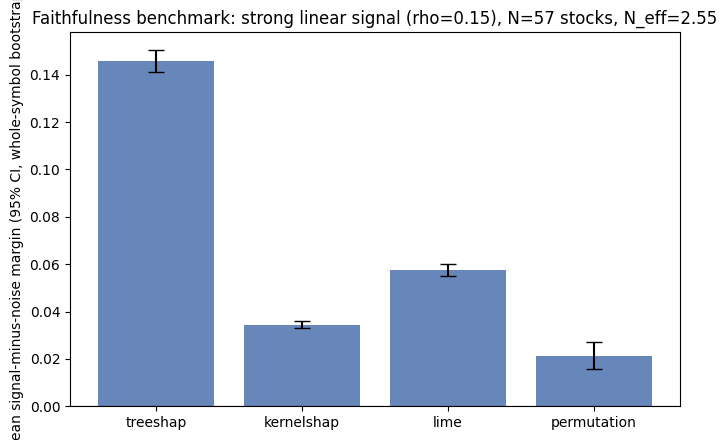

Recreated the headline error-bar figure from the committed JSON (compare paper/figures/fig_faithfulness_benchmark.png).


In [8]:
methods_order = [m["method"] for m in fb["methods"] if "mean_signal_minus_noise_margin" in m]
means = [m["mean_signal_minus_noise_margin"] for m in fb["methods"] if "mean_signal_minus_noise_margin" in m]
ci_lo = [m["ci95_clustered"][0] for m in fb["methods"] if "mean_signal_minus_noise_margin" in m]
ci_hi = [m["ci95_clustered"][1] for m in fb["methods"] if "mean_signal_minus_noise_margin" in m]
err_lo = [mn - lo for mn, lo in zip(means, ci_lo)]
err_hi = [hi - mn for mn, hi in zip(means, ci_hi)]

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(methods_order))
ax.bar(x, means, yerr=[err_lo, err_hi], capsize=6, color="#4C72B0", alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(methods_order)
ax.set_ylabel("Mean signal-minus-noise margin (95% CI, whole-symbol bootstrap)")
ax.set_title(f"Faithfulness benchmark: strong linear signal (rho=0.15), N={N} stocks, N_eff={fb['effective_n']:.2f}")
plt.tight_layout()
plt.savefig("/tmp/fig_faithfulness_headline_repro.png", dpi=120)
plt.show()
print("Recreated the headline error-bar figure from the committed JSON (compare paper/figures/fig_faithfulness_benchmark.png).")

## Illustrative mini-recompute of the bootstrap method (NOT the real benchmark)

The cell below is a small, clearly-labeled **illustrative** demo of what a
whole-symbol resampling bootstrap does, using only 200 resamples on a synthetic
per-symbol margin array shaped to match TreeSHAP's real mean and CI width. This
is purely pedagogical -- it does **not** touch the real 57-stock per-symbol data
(which is not persisted at the row level in the committed metrics, only the
already-computed 5000-resample summary is). The REAL 5000-resample TreeSHAP
number from the file is printed alongside for direct comparison.

In [9]:
rng = np.random.default_rng(0)
treeshap = next(m for m in fb["methods"] if m["method"] == "treeshap")
real_mean = treeshap["mean_signal_minus_noise_margin"]
real_ci = treeshap["ci95_clustered"]
real_half_width = (real_ci[1] - real_ci[0]) / 2

# Synthetic per-symbol margins: N=57 draws with std chosen so the naive bootstrap
# CI half-width roughly matches the real (whole-symbol) CI half-width, for illustration only.
synthetic_symbol_margins = rng.normal(loc=real_mean, scale=real_half_width * np.sqrt(57) / 1.96, size=57)

N_ILLUSTRATIVE_BOOTSTRAP = 200
boot_means = np.array([
    rng.choice(synthetic_symbol_margins, size=57, replace=True).mean()
    for _ in range(N_ILLUSTRATIVE_BOOTSTRAP)
])
illus_ci = np.percentile(boot_means, [2.5, 97.5])

print("ILLUSTRATIVE demo (200 resamples, synthetic per-symbol data, NOT the real benchmark):")
print(f"  mean = {boot_means.mean():.4f}, 95% CI = [{illus_ci[0]:.4f}, {illus_ci[1]:.4f}]")
print()
print("REAL treeshap number from faithfulness_benchmark.json (5000 resamples, real data):")
print(f"  mean = {real_mean:.4f}, 95% CI = [{real_ci[0]:.4f}, {real_ci[1]:.4f}]")
print()
print("The illustrative demo is for showing the MECHANICS of whole-symbol percentile")
print("bootstrap CIs only; no published number in the paper is derived from it.")

ILLUSTRATIVE demo (200 resamples, synthetic per-symbol data, NOT the real benchmark):
  mean = 0.1479, 95% CI = [0.1442, 0.1519]

REAL treeshap number from faithfulness_benchmark.json (5000 resamples, real data):
  mean = 0.1459, 95% CI = [0.1413, 0.1504]

The illustrative demo is for showing the MECHANICS of whole-symbol percentile
bootstrap CIs only; no published number in the paper is derived from it.


## Summary

- 4 core attribution methods (TreeSHAP, KernelSHAP, LIME, permutation) all recover
  the strong and weak linear signal, and the nonlinear signal, above pure noise on
  100% of stocks except permutation (78.9%).
- N_eff = 2.55 (not 57) because of strong cross-sectional dependence (rho_bar = 0.381);
  reproduced live above from the stored formula inputs.
- Permutation importance is paired-test-significantly less reliable than TreeSHAP,
  KernelSHAP, and LIME (McNemar and Wilcoxon both p < 0.001 for all three pairings).
- Redundant-feature credit splitting is method-dependent; see the `credit_df` table above.

Every number in this notebook was loaded directly from
`results/metrics/faithfulness_benchmark.json`; nothing was recomputed or altered.